In [1]:
import tensorflow as tf 
from keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory 
from tensorflow.keras import layers , models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import load_model
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix , classification_report
import os


In [2]:
dataset =image_dataset_from_directory(".\dataset\maize", image_size=(224 , 224) , batch_size=32)

Found 4188 files belonging to 4 classes.


In [3]:
train_dataset =image_dataset_from_directory(".\dataset\maize",validation_split=0.2, subset="training", seed=42, image_size=(224 , 224) , batch_size=32 , label_mode="categorical")
validation_dataset =image_dataset_from_directory(".\dataset\maize",validation_split=0.2, subset="validation", seed=42, image_size=(224 , 224) , batch_size=32 , label_mode="categorical")
class_names = train_dataset.class_names
print("class order:" , class_names)

Found 4188 files belonging to 4 classes.
Using 3351 files for training.
Found 4188 files belonging to 4 classes.
Using 837 files for validation.
class order: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
preprocess_layer = layers.Lambda(preprocess_input)

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.1)
])

In [7]:
num_classes = len(class_names)
base_model = tf.keras.applications.MobileNetV2(
    input_shape =(224,224, 3),
    include_top = False,
    weights = "imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224 , 224 , 3))
x = data_augmentation(inputs)
x = preprocess_layer(x)
x = base_model(x , training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes , activation="softmax")(x)

model = tf.keras.Model(inputs , outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
#history = model.fit(
 #   train_dataset,
  #  validation_data=validation_dataset,
   # epochs=10
#)

model = load_model(
    "maize_model_1.keras" ,
     custom_objects={"preprocess_input": preprocess_input}
)
print("model loaaded succesfully")

model loaaded succesfully


In [10]:
#model.save("maize_model_1.keras")

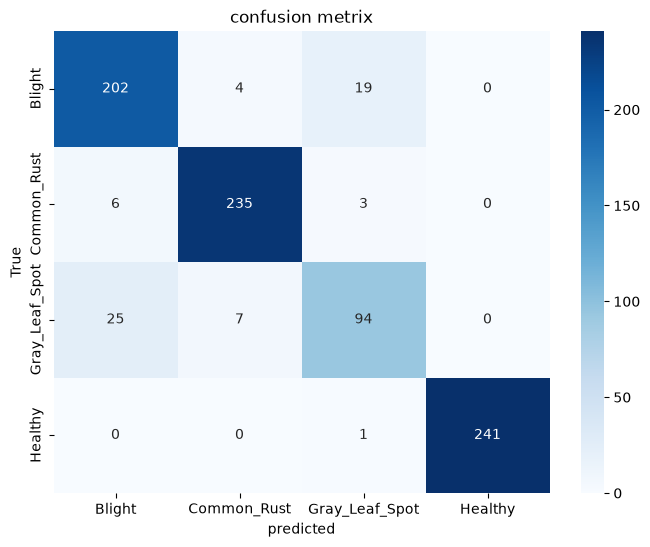

                precision    recall  f1-score   support

        Blight       0.87      0.90      0.88       225
   Common_Rust       0.96      0.96      0.96       244
Gray_Leaf_Spot       0.80      0.75      0.77       126
       Healthy       1.00      1.00      1.00       242

      accuracy                           0.92       837
     macro avg       0.91      0.90      0.90       837
  weighted avg       0.92      0.92      0.92       837



In [11]:
y_true = []
y_predict = []

for images , labels in validation_dataset:
    pred = model.predict(images , verbose=0)
    y_true.extend(np.argmax(labels.numpy() , axis=1))
    y_predict.extend(np.argmax(pred , axis=1))

cm = confusion_matrix(y_true , y_predict)
plt.figure(figsize=(8,6))
sns.heatmap(cm , annot=True , fmt="d" , xticklabels=class_names , yticklabels=class_names , cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("True")
plt.title("confusion metrix")
plt.show()    

print(classification_report(y_true,y_predict , target_names=class_names))


In [12]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categoricl_crossentropy" ,
    metrics=["accuracy"]
)

In [13]:
#fine_tune_history = model.fit(
 #   train_dataset, 
  #  validation_data=validation_dataset,
   # epochs=5
#)
#model.save("maize_finetune.keras")

model = load_model(
   "maize_finetune.keras" ,
   custom_objects={"preprocess_input": preprocess_input}
)
print("model loaaded succesfully")

model loaaded succesfully


In [14]:
y_true = []
y_predict = []

for images , labels in validation_dataset:
    pred = model.predict(images , verbose=0)
    y_true.extend(np.argmax(labels.numpy() , axis=1))
    y_predict.extend(np.argmax(pred , axis=1))

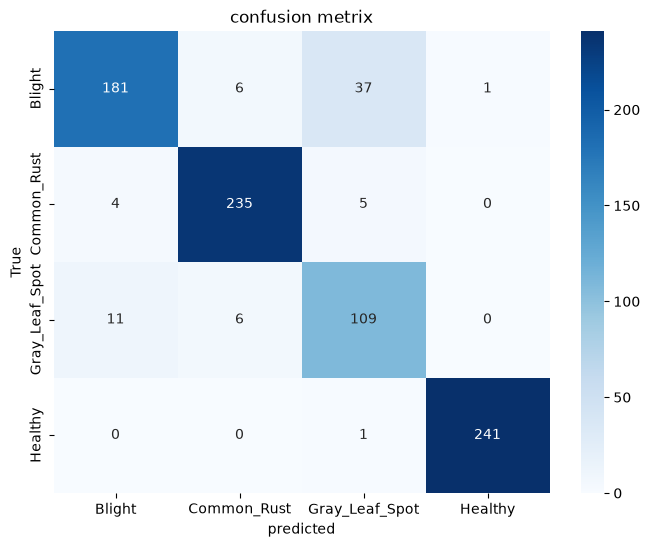

                precision    recall  f1-score   support

        Blight       0.92      0.80      0.86       225
   Common_Rust       0.95      0.96      0.96       244
Gray_Leaf_Spot       0.72      0.87      0.78       126
       Healthy       1.00      1.00      1.00       242

      accuracy                           0.92       837
     macro avg       0.90      0.91      0.90       837
  weighted avg       0.92      0.92      0.92       837



In [15]:
cm = confusion_matrix(y_true , y_predict)
plt.figure(figsize=(8,6))
sns.heatmap(cm , annot=True , fmt="d" , xticklabels=class_names , yticklabels=class_names , cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("True")
plt.title("confusion metrix")
plt.show()    

print(classification_report(y_true,y_predict , target_names=class_names))